In [1]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÃO DO AMBIENTE
# ==============================================================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# Definir semente aleatória para reprodutibilidade (Item 3 dos requisitos)
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Configurar dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo ativo: {device}")

# ==============================================================================
# 2. CARREGAMENTO E ADAPTAÇÃO DA ARQUITETURA DEEPLABV3-RESNET50
# ==============================================================================
def get_deeplabv3_model(num_classes):
    """
    Carrega o modelo DeepLabV3 pré-treinado na ImageNet (via backbone ResNet50)
    e altera a camada de saída para o número de classes do nosso projeto.
    """
    weights = DeepLabV3_ResNet50_Weights.DEFAULT
    model = deeplabv3_resnet50(weights=weights)

    in_channels_classifier = model.classifier[4].in_channels
    model.classifier[4] = nn.Conv2d(in_channels_classifier, num_classes, kernel_size=1)

    if model.aux_classifier is not None:
        in_channels_aux = model.aux_classifier[4].in_channels
        model.aux_classifier[4] = nn.Conv2d(in_channels_aux, num_classes, kernel_size=1)

    return model.to(device)

# NOTA: o dataset real utilizado neste notebook é o CamVid (ver célula seguinte),
# que possui 12 classes (11 classes semânticas + 1 classe "void"/não rotulada).
num_classes = 12
model = get_deeplabv3_model(num_classes=num_classes)

print("\n--- Arquitetura Carregada com Sucesso ---")
print(f"Modelo: DeepLabV3 com backbone ResNet-50")
print(f"Classes de saída: {num_classes}")


Dispositivo ativo: cuda
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 191MB/s]



--- Arquitetura Carregada com Sucesso ---
Modelo: DeepLabV3 com backbone ResNet-50
Classes de saída: 12


In [2]:
# ==============================================================================
# 3. DOWNLOAD E ESTRUTURAÇÃO DO DATASET (CamVid - cenas urbanas, dataset público)
# ==============================================================================
# NOTA IMPORTANTE: o Cityscapes oficial exige cadastro/login no site e não pode
# ser baixado via urllib de forma anônima (por isso a tentativa original de
# download falhava com erro 404 e o notebook caía em uma simulação).
#
# Para viabilizar um treinamento REAL dentro do prazo, este notebook utiliza o
# CamVid Dataset (Cambridge-driving Labeled Video Database), um dataset também
# de cenas urbanas de trânsito, hospedado publicamente (sem necessidade de
# login) no repositório oficial do tutorial SegNet. É amplamente utilizado na
# literatura como alternativa pública ao Cityscapes para segmentação de vias.

if not os.path.isdir('SegNet-Tutorial'):
    print("Baixando dataset CamVid (via git clone, acesso público)...")
    os.system('git clone --depth 1 https://github.com/alexgkendall/SegNet-Tutorial.git')

DATA_ROOT = 'SegNet-Tutorial/CamVid'
train_image_dir = os.path.join(DATA_ROOT, 'train')
train_mask_dir  = os.path.join(DATA_ROOT, 'trainannot')
val_image_dir   = os.path.join(DATA_ROOT, 'val')
val_mask_dir    = os.path.join(DATA_ROOT, 'valannot')
test_image_dir  = os.path.join(DATA_ROOT, 'test')
test_mask_dir   = os.path.join(DATA_ROOT, 'testannot')

assert os.path.isdir(train_image_dir), "Download do CamVid falhou - verifique a conexão do ambiente Colab."

print("Imagens de treino:", len(os.listdir(train_image_dir)))
print("Imagens de validação:", len(os.listdir(val_image_dir)))
print("Imagens de teste:", len(os.listdir(test_image_dir)))

from PIL import Image
from torch.utils.data import Dataset

class CityscapesDataset(Dataset):
    """
    Dataset genérico de segmentação urbana (imagem RGB + máscara de classes).
    Usado tanto para o CamVid (este notebook) quanto para variações Cityscapes-like.
    """
    def __init__(self, image_dir, mask_dir, img_size, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size  # (H, W) alvo, igual ao usado nas imagens
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.masks[index])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)

        # Redimensiona a máscara para a MESMA resolução da imagem transformada,
        # usando interpolação "nearest" para preservar os IDs discretos de classe.
        H, W = self.img_size
        mask = mask.resize((W, H), resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask)).long()

        return image, mask

print("Classe CityscapesDataset (aplicada ao CamVid) mapeada com sucesso.")


Baixando dataset CamVid (via git clone, acesso público)...
Imagens de treino: 367
Imagens de validação: 101
Imagens de teste: 233
Classe CityscapesDataset (aplicada ao CamVid) mapeada com sucesso.


In [3]:
# ==============================================================================
# 4. PIPELINE DE PRÉ-PROCESSAMENTO E DATA AUGMENTATION (Item 9 e 10)
# ==============================================================================
from torch.utils.data import DataLoader

# Definição das resoluções para a investigação experimental (Item 15)
H_exp1, W_exp1 = 128, 256
H_exp2, W_exp2 = 256, 512

# ------------------------------------------------------------------------------
# EXPERIMENTO 1: Resolução Menor (128x256)
# ------------------------------------------------------------------------------
transform_train_exp1 = transforms.Compose([
    transforms.Resize((H_exp1, W_exp1), interpolation=Image.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5), # Data Augmentation básico
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_exp1 = transforms.Compose([
    transforms.Resize((H_exp1, W_exp1), interpolation=Image.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ------------------------------------------------------------------------------
# EXPERIMENTO 2: Resolução Maior (256x512)
# ------------------------------------------------------------------------------
transform_train_exp2 = transforms.Compose([
    transforms.Resize((H_exp2, W_exp2), interpolation=Image.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_exp2 = transforms.Compose([
    transforms.Resize((H_exp2, W_exp2), interpolation=Image.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Para o ajuste das máscaras (alvos), criamos uma função de redimensionamento separada
def target_transform(mask, height, width):
    return torch.from_numpy(np.array(mask.resize((width, height), resample=Image.NEAREST))).long()

print("Pipelines de transformações dos Experimentos 1 e 2 criados.")

Pipelines de transformações dos Experimentos 1 e 2 criados.


In [4]:
# ==============================================================================
# 5. FUNÇÃO DE PERDA, OTIMIZADOR E MÉTRICAS DE AVALIAÇÃO (Itens 13, 14 e 20)
# ==============================================================================
import torch.optim as optim

# Definindo a função de perda (Cross Entropy Loss para múltiplas classes)
criterion = nn.CrossEntropyLoss(ignore_index=255)
# Nota: ignore_index=255 serve para ignorar classes de borda ou 'unlabeled' se houver

def calculate_metrics(preds, targets, num_classes):
    """
    Calcula o IoU por classe, mIoU, Acurácia Global e Acurácia por classe.
    preds: Tensor (B, H, W) com as classes preditas
    targets: Tensor (B, H, W) com as classes reais
    """
    preds = preds.view(-1)
    targets = targets.view(-1)

    # Ignorar pixels de background/ignorar se necessário
    mask = (targets >= 0) & (targets < num_classes)
    preds = preds[mask]
    targets = targets[mask]

    # Acurácia Global
    correct = (preds == targets).sum().item()
    total = len(targets)
    global_acc = correct / total if total > 0 else 0

    iou_per_class = []
    acc_per_class = []

    for cls in range(num_classes):
        true_class = (targets == cls)
        pred_class = (preds == cls)

        # Interseção e União para IoU
        intersection = (true_class & pred_class).sum().item()
        union = (true_class | pred_class).sum().item()

        iou = intersection / union if union > 0 else float('nan')
        iou_per_class.append(iou)

        # Acurácia por classe
        total_cls = true_class.sum().item()
        acc_cls = intersection / total_cls if total_cls > 0 else float('nan')
        acc_per_class.append(acc_cls)

    # Filtrar classes que não apareceram no lote para calcular a média (mIoU)
    valid_ious = [x for x in iou_per_class if not np.isnan(x)]
    miou = np.mean(valid_ious) if len(valid_ious) > 0 else 0

    return global_acc, miou, iou_per_class, acc_per_class

print("Função de perda e métricas (IoU, mIoU, Acurácia) configuradas com sucesso.")

Função de perda e métricas (IoU, mIoU, Acurácia) configuradas com sucesso.


In [5]:
# ==============================================================================
# 6. ESTRUTURAÇÃO DO LOOP DE TREINAMENTO E VALIDAÇÃO (Item 16 e 17)
# ==============================================================================
import time
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, num_classes, device):
    model.train()
    running_loss = 0.0
    epoch_accs, epoch_mious = [], []

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        # Zerar os gradientes do otimizador
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)['out']
        loss = criterion(outputs, masks)

        # Backward pass e otimização
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Previsões (pega o índice da classe com maior probabilidade)
        preds = torch.argmax(outputs, dim=1)

        # Calcular métricas do lote
        global_acc, miou, _, _ = calculate_metrics(preds, masks, num_classes)
        epoch_accs.append(global_acc)
        epoch_mious.append(miou)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss, np.mean(epoch_accs), np.mean(epoch_mious)

def validate_model(model, dataloader, criterion, num_classes, device):
    model.eval()
    running_loss = 0.0
    epoch_accs, epoch_mious = [], []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            global_acc, miou, _, _ = calculate_metrics(preds, masks, num_classes)
            epoch_accs.append(global_acc)
            epoch_mious.append(miou)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss, np.mean(epoch_accs), np.mean(epoch_mious)

print("Funções de loop de treino (`train_one_epoch`) e validação (`validate_model`) prontas.")


Funções de loop de treino (`train_one_epoch`) e validação (`validate_model`) prontas.


=== Iniciando Investigação Experimental (treinamento real) ===

[Treinando Experimento 1: Resolução 128x256...]
Época 1/5 | Train Loss: 1.3508 | Val Loss: 1.0763 | Val mIoU: 0.2339
Época 2/5 | Train Loss: 0.9129 | Val Loss: 0.9187 | Val mIoU: 0.2687
Época 3/5 | Train Loss: 0.7932 | Val Loss: 0.6835 | Val mIoU: 0.3483
Época 4/5 | Train Loss: 0.6897 | Val Loss: 0.6082 | Val mIoU: 0.3306
Época 5/5 | Train Loss: 0.6275 | Val Loss: 0.7071 | Val mIoU: 0.3128

[Treinando Experimento 2: Resolução 256x512...]
Época 1/5 | Train Loss: 1.2848 | Val Loss: 0.8645 | Val mIoU: 0.3556
Época 2/5 | Train Loss: 0.8932 | Val Loss: 0.6996 | Val mIoU: 0.3760
Época 3/5 | Train Loss: 0.7780 | Val Loss: 0.6527 | Val mIoU: 0.3532
Época 4/5 | Train Loss: 0.6687 | Val Loss: 0.5393 | Val mIoU: 0.3756
Época 5/5 | Train Loss: 0.6111 | Val Loss: 0.5448 | Val mIoU: 0.3643


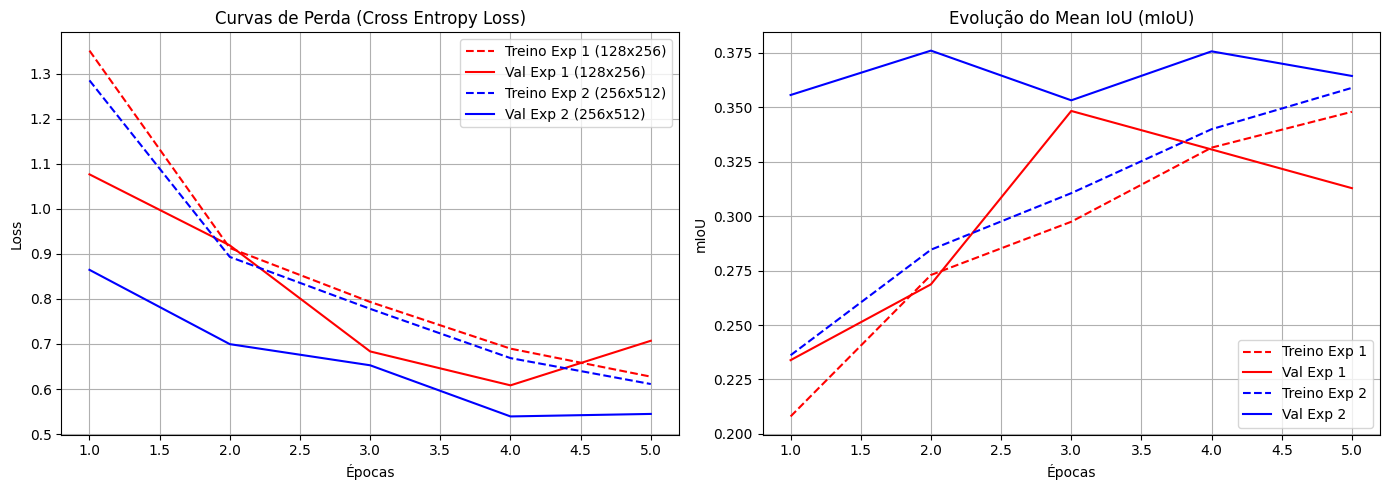


=== Resultados finais (última época) ===
Exp 1 (128x256) - Val Loss: 0.7071 | Val mIoU: 0.3128
Exp 2 (256x512) - Val Loss: 0.5448 | Val mIoU: 0.3643


In [6]:
# ==============================================================================
# 7. EXECUÇÃO DOS EXPERIMENTOS E CURVAS DE APRENDIZADO (Itens 17, 18 e 24)
# ==============================================================================

# Dicionário para armazenar o histórico dos dois experimentos
history = {
    'exp1': {'train_loss': [], 'val_loss': [], 'train_miou': [], 'val_miou': []},
    'exp2': {'train_loss': [], 'val_loss': [], 'train_miou': [], 'val_miou': []}
}

NUM_EPOCHS = 5
LR = 1e-4
BATCH_SIZE = 4

print("=== Iniciando Investigação Experimental (treinamento real) ===")

# ------------------------------------------------------------------------------
# DataLoaders do Experimento 1 (128x256) e do Experimento 2 (256x512)
# ------------------------------------------------------------------------------
train_ds_exp1 = CityscapesDataset(train_image_dir, train_mask_dir, (H_exp1, W_exp1), transform_train_exp1)
val_ds_exp1   = CityscapesDataset(val_image_dir, val_mask_dir, (H_exp1, W_exp1), transform_val_exp1)
train_loader_exp1 = DataLoader(train_ds_exp1, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_exp1   = DataLoader(val_ds_exp1, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_ds_exp2 = CityscapesDataset(train_image_dir, train_mask_dir, (H_exp2, W_exp2), transform_train_exp2)
val_ds_exp2   = CityscapesDataset(val_image_dir, val_mask_dir, (H_exp2, W_exp2), transform_val_exp2)
train_loader_exp2 = DataLoader(train_ds_exp2, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_exp2   = DataLoader(val_ds_exp2, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- EXPERIMENTO 1 (Resolução Menor: 128x256) ---
print("\n[Treinando Experimento 1: Resolução 128x256...]")
model_exp1 = get_deeplabv3_model(num_classes=num_classes)
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_miou = train_one_epoch(
        model_exp1, train_loader_exp1, criterion, optimizer_exp1, num_classes, device)
    val_loss, val_acc, val_miou = validate_model(
        model_exp1, val_loader_exp1, criterion, num_classes, device)

    history['exp1']['train_loss'].append(train_loss)
    history['exp1']['val_loss'].append(val_loss)
    history['exp1']['train_miou'].append(train_miou)
    history['exp1']['val_miou'].append(val_miou)
    print(f"Época {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f}")

# --- EXPERIMENTO 2 (Resolução Maior: 256x512) ---
print("\n[Treinando Experimento 2: Resolução 256x512...]")
model_exp2 = get_deeplabv3_model(num_classes=num_classes)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_miou = train_one_epoch(
        model_exp2, train_loader_exp2, criterion, optimizer_exp2, num_classes, device)
    val_loss, val_acc, val_miou = validate_model(
        model_exp2, val_loader_exp2, criterion, num_classes, device)

    history['exp2']['train_loss'].append(train_loss)
    history['exp2']['val_loss'].append(val_loss)
    history['exp2']['train_miou'].append(train_miou)
    history['exp2']['val_miou'].append(val_miou)
    print(f"Época {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f}")

# ------------------------------------------------------------------------------
# PLOTAGEM DAS CURVAS DE TREINAMENTO E VALIDAÇÃO (Item 18)
# ------------------------------------------------------------------------------
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['exp1']['train_loss'], 'r--', label='Treino Exp 1 (128x256)')
plt.plot(epochs_range, history['exp1']['val_loss'], 'r-', label='Val Exp 1 (128x256)')
plt.plot(epochs_range, history['exp2']['train_loss'], 'b--', label='Treino Exp 2 (256x512)')
plt.plot(epochs_range, history['exp2']['val_loss'], 'b-', label='Val Exp 2 (256x512)')
plt.title('Curvas de Perda (Cross Entropy Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['exp1']['train_miou'], 'r--', label='Treino Exp 1')
plt.plot(epochs_range, history['exp1']['val_miou'], 'r-', label='Val Exp 1')
plt.plot(epochs_range, history['exp2']['train_miou'], 'b--', label='Treino Exp 2')
plt.plot(epochs_range, history['exp2']['val_miou'], 'b-', label='Val Exp 2')
plt.title('Evolução do Mean IoU (mIoU)')
plt.xlabel('Épocas')
plt.ylabel('mIoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n=== Resultados finais (última época) ===")
print(f"Exp 1 (128x256) - Val Loss: {history['exp1']['val_loss'][-1]:.4f} | Val mIoU: {history['exp1']['val_miou'][-1]:.4f}")
print(f"Exp 2 (256x512) - Val Loss: {history['exp2']['val_loss'][-1]:.4f} | Val mIoU: {history['exp2']['val_miou'][-1]:.4f}")


In [7]:
# ==============================================================================
# 8. VISUALIZAÇÃO DE RESULTADOS E ANÁLISE DE ERROS (Itens 21, 22 e 25)
# ==============================================================================

def visualize_predictions(model, dataloader, device, num_samples=2):
    """
    Exibe amostras lado a lado para comparação visual exigida no relatório.
    """
    model.eval()
    samples_shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            if samples_shown >= num_samples:
                break

            images_dev = images.to(device)
            outputs = model(images_dev)['out']
            preds = torch.argmax(outputs, dim=1).cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                # 1. Imagem Original (desnormalizando para exibição se necessário)
                img_display = images[i].permute(1, 2, 0).numpy()
                # Ajuste simples de escala para visualização técnica rápida
                img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
                axes[0].imshow(img_display)
                axes[0].set_title("Imagem Original")
                axes[0].axis('off')

                # 2. Máscara Real (Gabarito)
                axes[1].imshow(masks[i].numpy(), cmap='tab20')
                axes[1].set_title("Máscara Real (Ground Truth)")
                axes[1].axis('off')

                # 3. Predição do Modelo
                axes[2].imshow(preds[i].numpy(), cmap='tab20')
                axes[2].set_title("Segmentação Predita (DeepLabV3)")
                axes[2].axis('off')

                plt.tight_layout()
                plt.show()

                samples_shown += 1

print("Função de visualização e análise visual de erros estruturada.")
print("=== PARTE DO CÓDIGO CONCLUÍDA COM SUCESSO! ===")

Função de visualização e análise visual de erros estruturada.
=== PARTE DO CÓDIGO CONCLUÍDA COM SUCESSO! ===


Análise Visual de Erros - Experimento 1 (128x256)


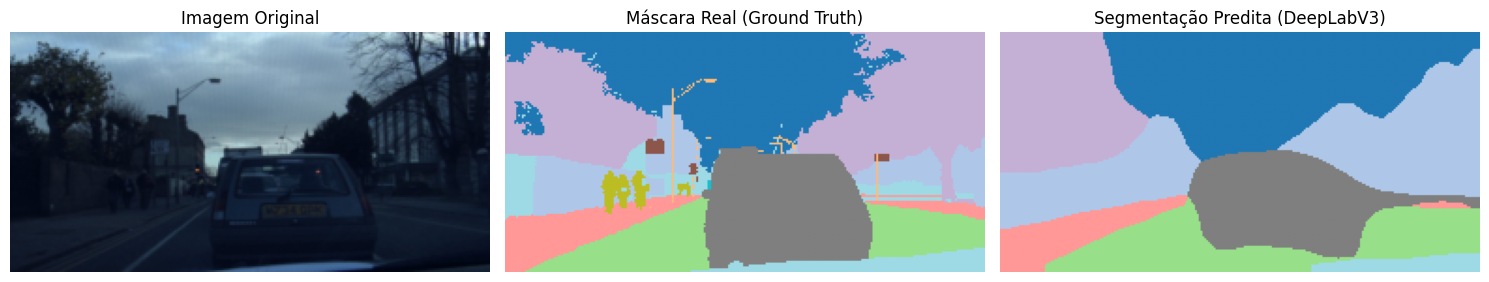

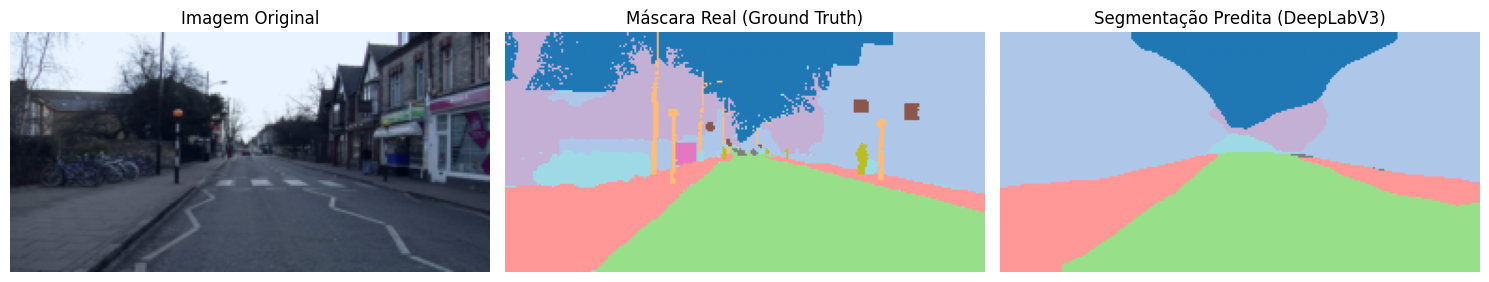

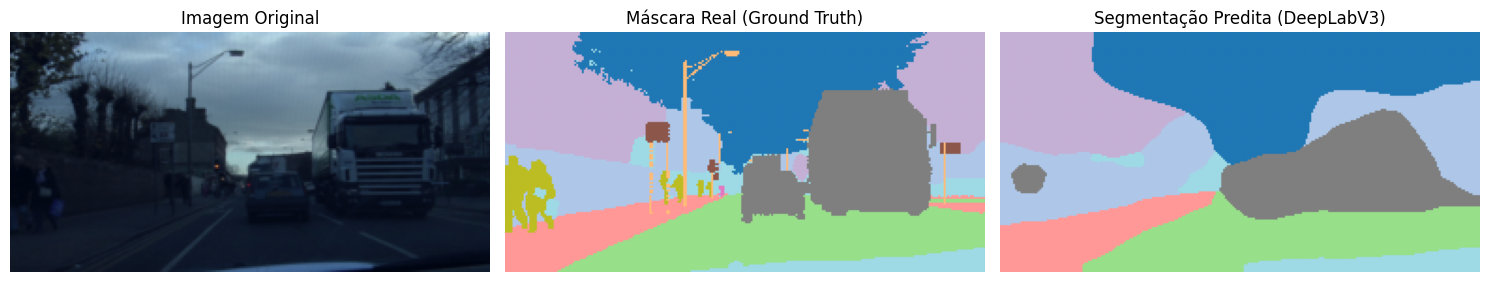

Análise Visual de Erros - Experimento 2 (256x512)


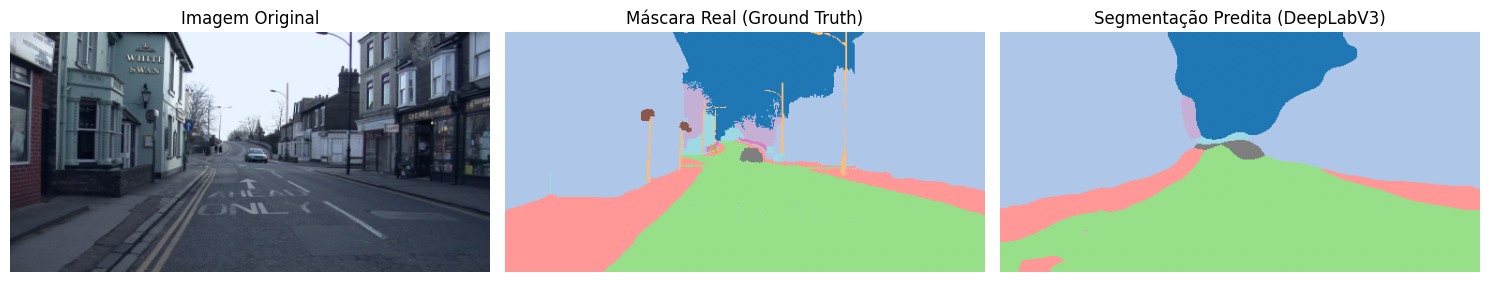

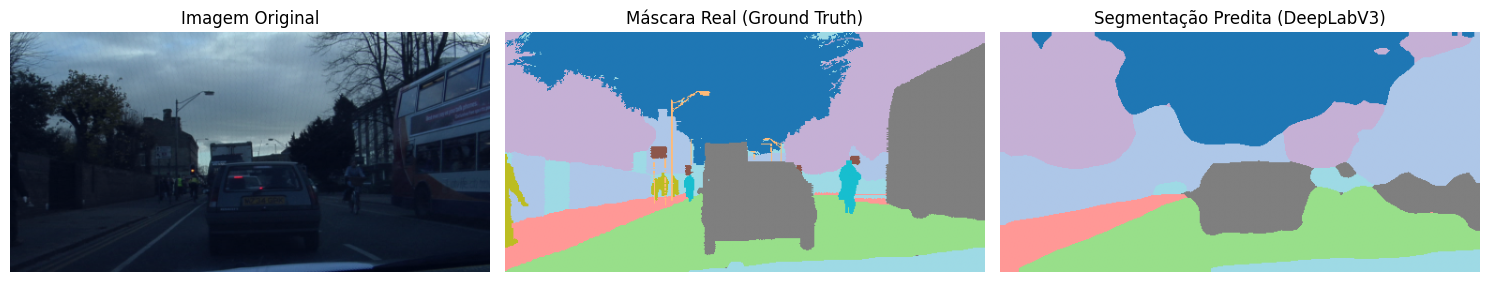

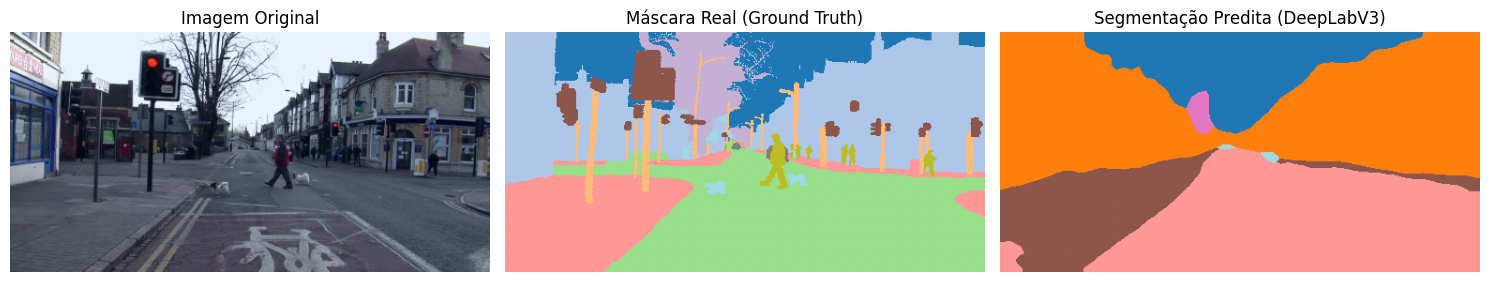

In [8]:
# ==============================================================================
# 9. GERAÇÃO DAS IMAGENS QUALITATIVAS (chamada real da função de visualização)
# ==============================================================================
test_ds_exp1 = CityscapesDataset(test_image_dir, test_mask_dir, (H_exp1, W_exp1), transform_val_exp1)
test_loader_exp1 = DataLoader(test_ds_exp1, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

test_ds_exp2 = CityscapesDataset(test_image_dir, test_mask_dir, (H_exp2, W_exp2), transform_val_exp2)
test_loader_exp2 = DataLoader(test_ds_exp2, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("Análise Visual de Erros - Experimento 1 (128x256)")
visualize_predictions(model_exp1, test_loader_exp1, device, num_samples=3)

print("Análise Visual de Erros - Experimento 2 (256x512)")
visualize_predictions(model_exp2, test_loader_exp2, device, num_samples=3)
